<a href="https://colab.research.google.com/github/Ishita1609/Ishita-Singh/blob/main/EDA_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) - Phase 1
### Name: Ishita Singh
### Register Number: 23BDS0189
### Dataset: VerbAgg.csv

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")



1. Loading the Dataset


In [19]:
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/VerbAgg.csv"

df = pd.read_csv(url)

df.head()

,rownames,Anger,Gender,item,resp,id,btype,situ,mode,r2
0,1,20,M,S1WantCurse,no,1,curse,other,want,N
1,2,11,M,S1WantCurse,no,2,curse,other,want,N
2,3,17,F,S1WantCurse,perhaps,3,curse,other,want,Y
3,4,21,F,S1WantCurse,perhaps,4,curse,other,want,Y
4,5,17,F,S1WantCurse,perhaps,5,curse,other,want,Y


2. Basic Statistical Analysis

In [ ]:
df.shape

(7584, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7584 entries, 0 to 7583
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  7584 non-null   int64 
 1   Anger     7584 non-null   int64 
 2   Gender    7584 non-null   object
 3   item      7584 non-null   object
 4   resp      7584 non-null   object
 5   id        7584 non-null   int64 
 6   btype     7584 non-null   object
 7   situ      7584 non-null   object
 8   mode      7584 non-null   object
 9   r2        7584 non-null   object
dtypes: int64(3), object(7)
memory usage: 592.6+ KB


In [ ]:
df.describe(include='all')

,rownames,Anger,Gender,item,resp,id,btype,situ,mode,r2
count,7584.000000,7584.000000,7584,7584,7584,7584.0000,7584,7584,7584,7584
unique,NaN,NaN,2,24,3,NaN,3,2,2,2
top,NaN,NaN,F,S1WantCurse,no,NaN,curse,other,want,N
freq,NaN,NaN,5832,316,3973,NaN,2528,3792,3792,3973
mean,3792.500000,20.003165,NaN,NaN,NaN,158.5000,NaN,NaN,NaN,NaN
std,2189.456554,4.841139,NaN,NaN,NaN,91.2269,NaN,NaN,NaN,NaN
min,1.000000,11.000000,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,NaN
25%,1896.750000,17.000000,NaN,NaN,NaN,79.7500,NaN,NaN,NaN,NaN
50%,3792.500000,19.000000,NaN,NaN,NaN,158.5000,NaN,NaN,NaN,NaN
75%,5688.250000,23.000000,NaN,NaN,NaN,237.2500,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['rownames', 'Anger', 'Gender', 'item', 'resp', 'id', 'btype', 'situ',
       'mode', 'r2'],
      dtype='object')

In [ ]:
df.dtypes

,0
rownames,int64
Anger,int64
Gender,object
item,object
resp,object
id,int64
btype,object
situ,object
mode,object
r2,object


In [ ]:
df.nunique()

,0
rownames,7584
Anger,26
Gender,2
item,24
resp,3
id,316
btype,3
situ,2
mode,2
r2,2


3. Handling missing data




In [ ]:
df.isnull().sum()

,0
rownames,0
Anger,0
Gender,0
item,0
resp,0
id,0
btype,0
situ,0
mode,0
r2,0


In [ ]:
if df.isnull().sum().sum() == 0:
    print("No missing values found.")
else:
    print("Missing values found.")

No missing values found.


4. Data cleaning

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


5. Data Transformation

In [ ]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = encoder.fit_transform(df[col])

df.head()

,rownames,Anger,Gender,item,resp,id,btype,situ,mode,r2
0,1,20,1,3,0,1,0,0,1,0
1,2,11,1,3,0,2,0,0,1,0
2,3,17,0,3,1,3,0,0,1,1
3,4,21,0,3,1,4,0,0,1,1
4,5,17,0,3,1,5,0,0,1,1


In [ ]:
scaler = StandardScaler()

numeric = df.select_dtypes(include=np.number).columns

df[numeric] = scaler.fit_transform(df[numeric])


6. Univariate analysis with a minimum of three visualizations

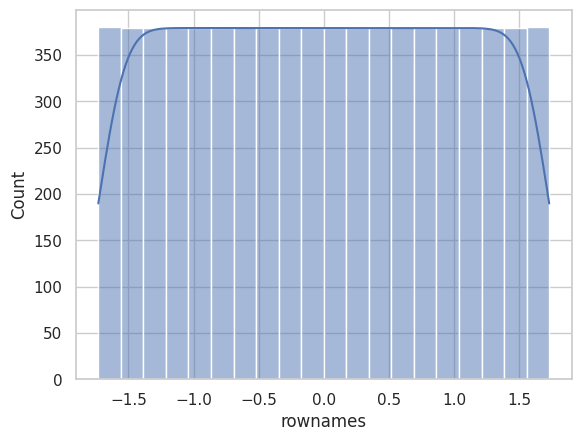

In [ ]:
sns.histplot(df.iloc[:,0], kde=True)

plt.show()

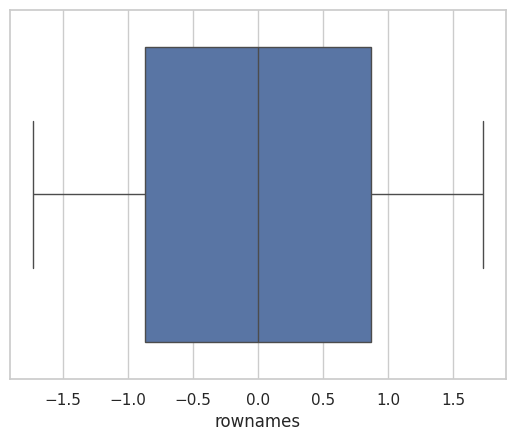

In [ ]:
sns.boxplot(x=df.iloc[:,0])

plt.show()

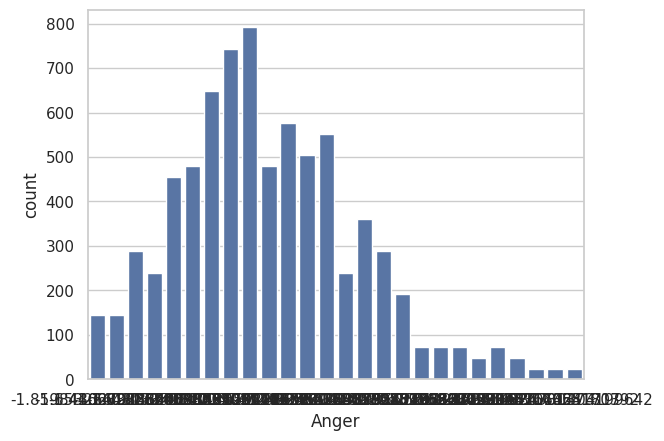

In [ ]:
sns.countplot(x=df.iloc[:,1])

plt.show()

7. Bivariate analysis with a minimum of three visualizations



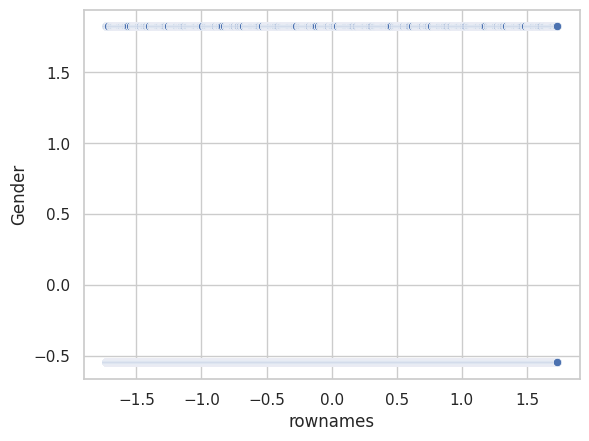

In [ ]:
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,2])

plt.show()

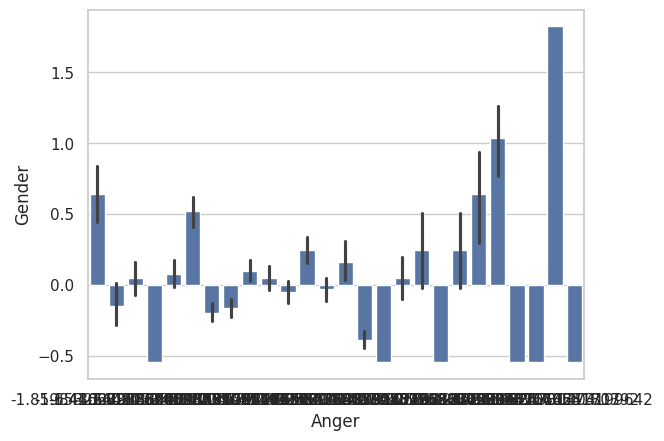

In [ ]:
sns.barplot(x=df.iloc[:,1], y=df.iloc[:,2])

plt.show()

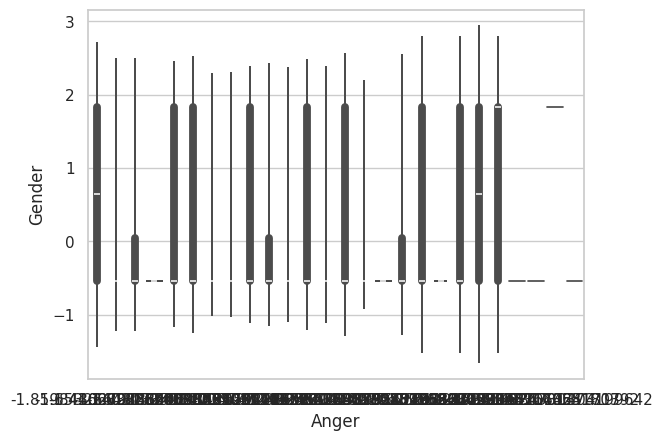

In [ ]:
sns.violinplot(x=df.iloc[:,1], y=df.iloc[:,2])

plt.show()


8. Multivariate analysis with a minimum of three visualizations



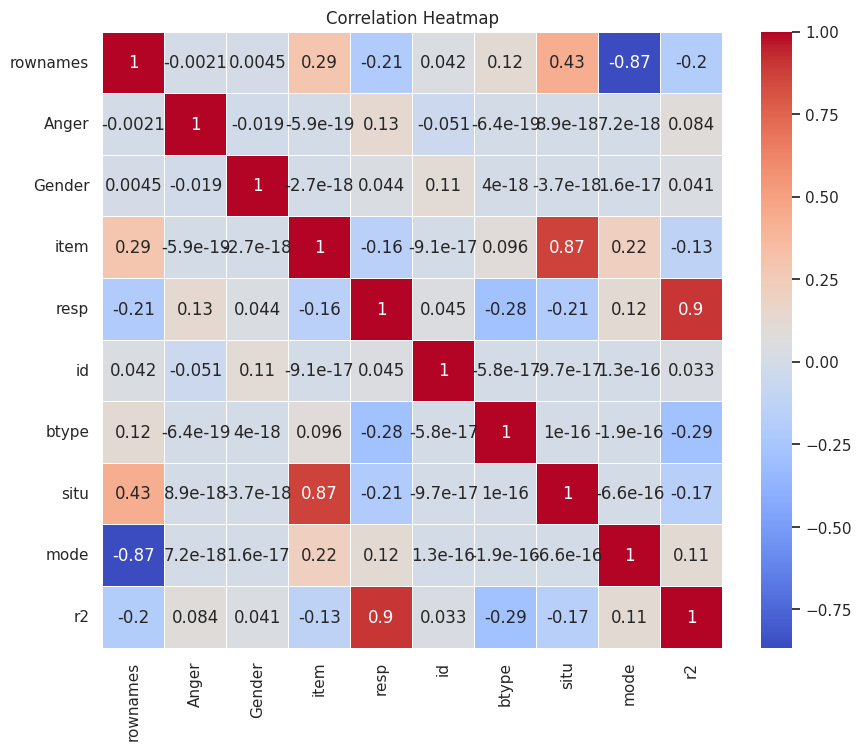

In [ ]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

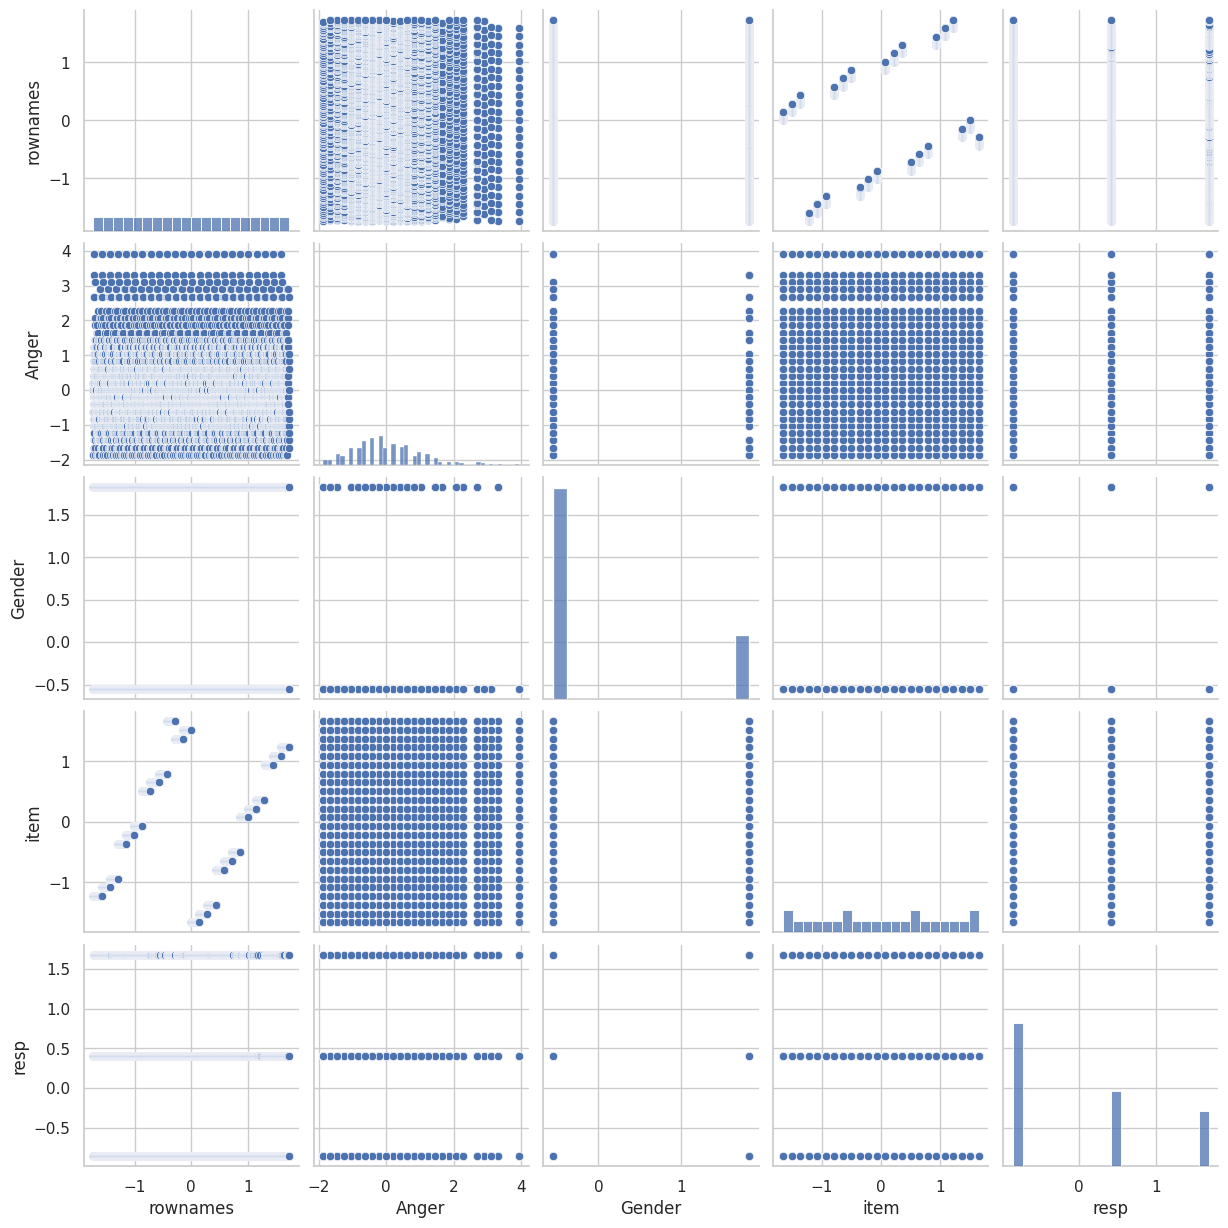

In [ ]:
numeric_df = df.select_dtypes(include="number")

sns.pairplot(numeric_df.iloc[:, :5])

plt.show()

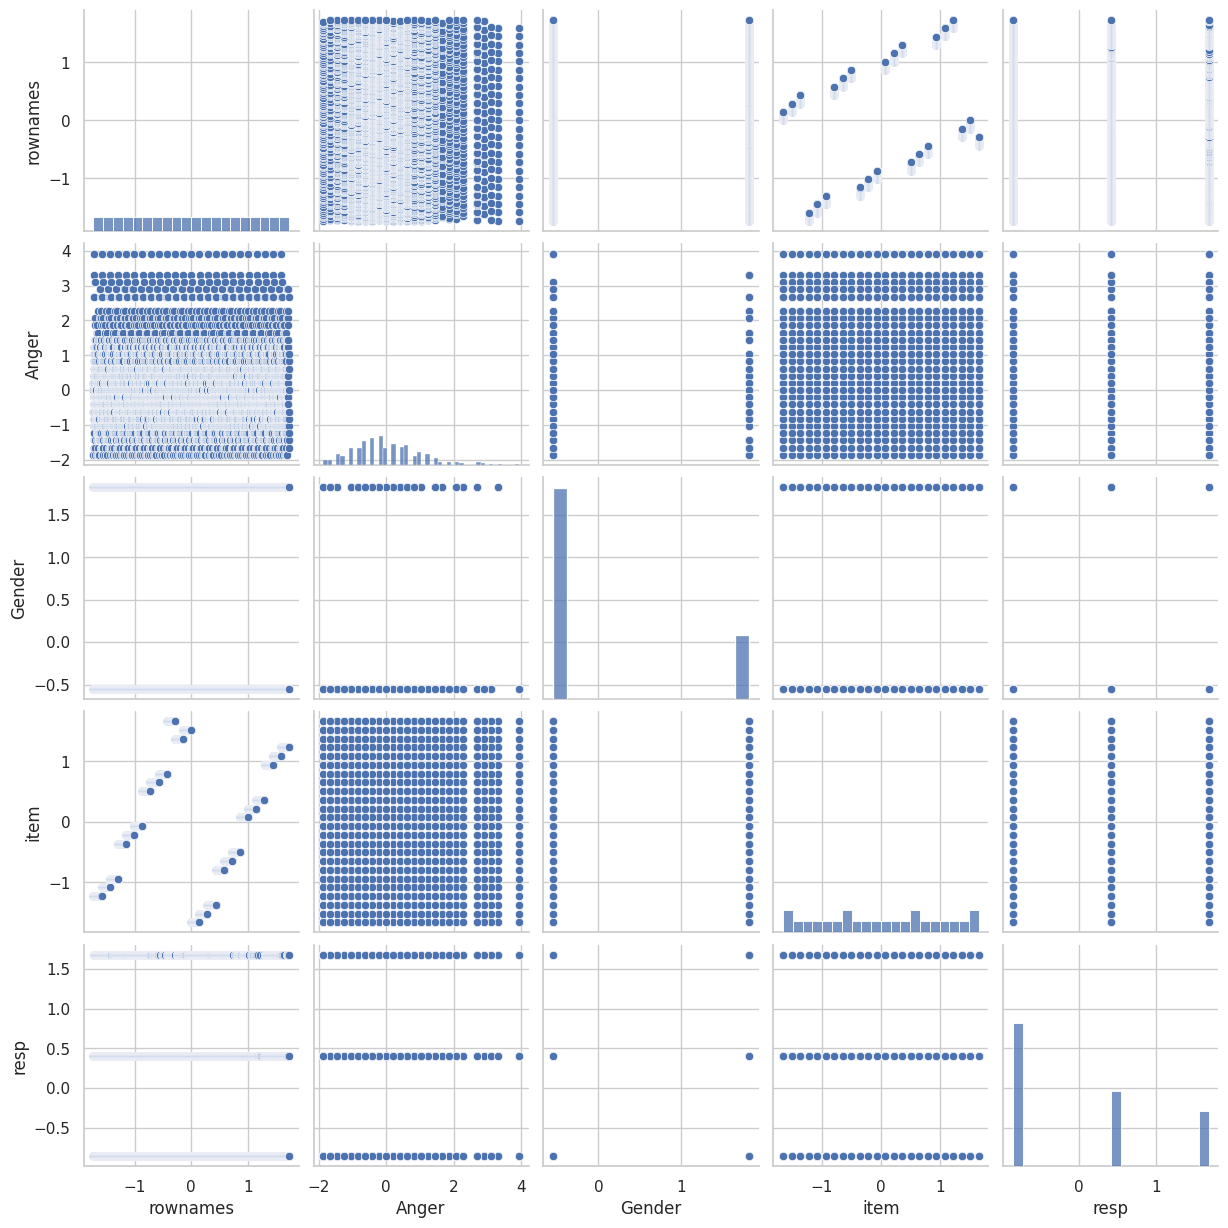

In [ ]:
numeric_df = df.select_dtypes(include="number")

sns.pairplot(
    numeric_df.iloc[:, :5],
    diag_kind="hist"
)

plt.show()

Conclusion

- Successfully loaded the VerbAgg dataset.
- Performed statistical analysis to understand the dataset.
- Checked for missing values and duplicate records.
- Applied data cleaning and transformation techniques.
- Conducted univariate, bivariate and multivariate analyses.
- Generated multiple visualizations to understand the data distribution and relationships among variables.

# Exploratory Data Analysis (EDA) - Phase 2

### Name: Ishita Singh
### Registration Number: 23BDS0189
### Dataset: VerbAgg.csv

Phase II focuses on 1D, 2D and 3D statistical analyses, along with K-Means and Hierarchical clustering.

In [45]:
# Load the original dataset for Phase II

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/VerbAgg.csv"

df_phase2 = pd.read_csv(url)

df_phase2.drop_duplicates(inplace=True)

encoder_phase2 = LabelEncoder()

for col in df_phase2.select_dtypes(include="object"):
    df_phase2[col] = encoder_phase2.fit_transform(df_phase2[col])

print("Dataset shape:", df_phase2.shape)

Dataset shape: (7584, 10)


1D Statistical Analysis

In [59]:
numeric_cols = ["rownames", "Anger", "id"]

print("Numerical columns:")
print(numeric_cols)

Numerical columns:
['rownames', 'Anger', 'id']


In [60]:
# Descriptive statistics

stats = pd.DataFrame({
    "Mean": df_phase2[numeric_cols].mean(),
    "Median": df_phase2[numeric_cols].median(),
    "Mode": df_phase2[numeric_cols].mode().iloc[0],
    "Variance": df_phase2[numeric_cols].var(),
    "Standard Deviation": df_phase2[numeric_cols].std(),
    "Minimum": df_phase2[numeric_cols].min(),
    "Maximum": df_phase2[numeric_cols].max(),
    "Q1": df_phase2[numeric_cols].quantile(0.25),
    "Q3": df_phase2[numeric_cols].quantile(0.75)
})

stats["IQR"] = stats["Q3"] - stats["Q1"]

stats

,Mean,Median,Mode,Variance,Standard Deviation,Minimum,Maximum,Q1,Q3,IQR
rownames,3792.500000,3792.5,1.0,4.793720e+06,2189.456554,1,7584,1896.75,5688.25,3791.5
Anger,20.003165,19.0,19.0,2.343662e+01,4.841139,11,39,17.00,23.00,6.0
id,158.500000,158.5,1.0,8.322347e+03,91.226900,1,316,79.75,237.25,157.5


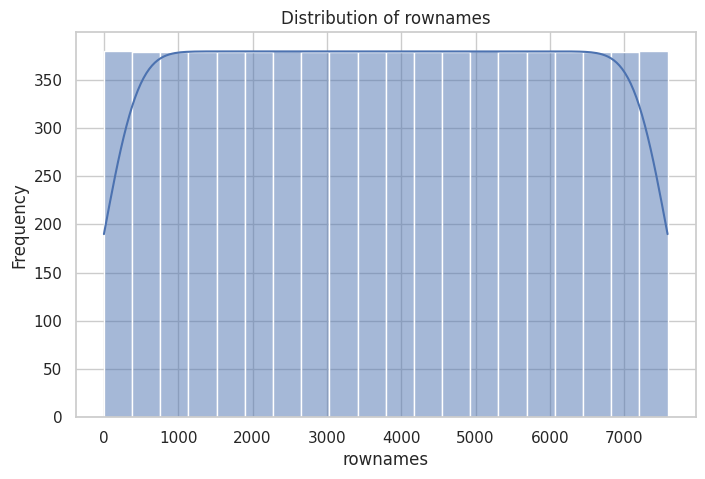

In [61]:
# Histogram

plt.figure(figsize=(8,5))

sns.histplot(
    df_phase2[numeric_cols[0]],
    kde=True
)

plt.title(f"Distribution of {numeric_cols[0]}")
plt.xlabel(numeric_cols[0])
plt.ylabel("Frequency")

plt.show()

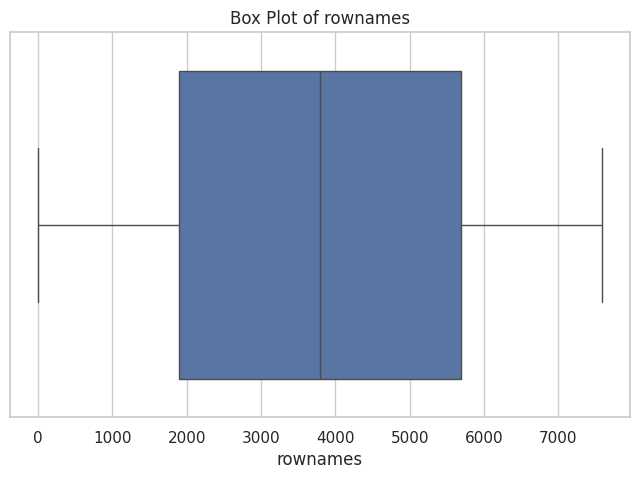

In [62]:
# Box plot

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_phase2[numeric_cols[0]]
)

plt.title(f"Box Plot of {numeric_cols[0]}")
plt.xlabel(numeric_cols[0])

plt.show()

2D Statistical Analysis

In [63]:
# Correlation matrix

correlation = df_phase2[numeric_cols].corr()

correlation

,rownames,Anger,id
rownames,1.000000,-0.002113,0.041666
Anger,-0.002113,1.000000,-0.050706
id,0.041666,-0.050706,1.000000


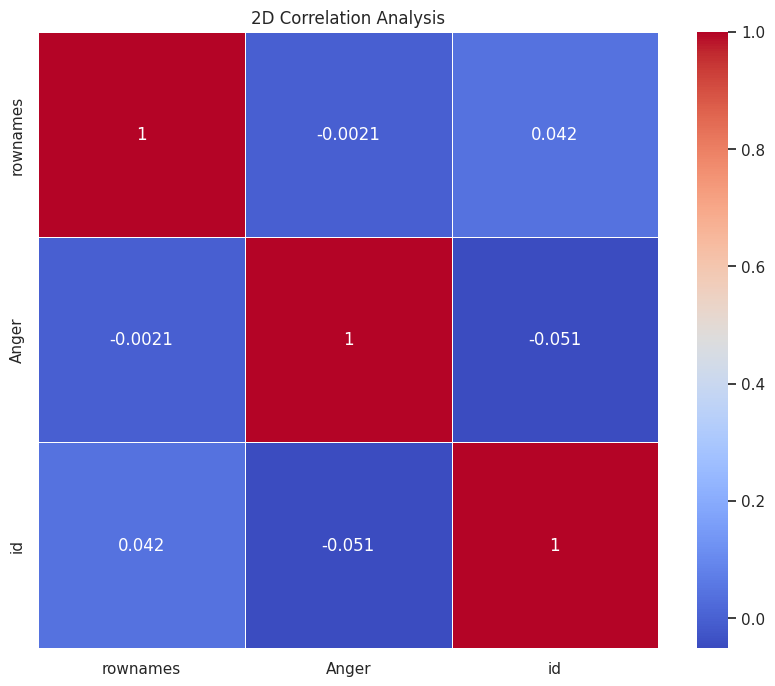

In [64]:
# Correlation heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("2D Correlation Analysis")

plt.show()

In [65]:
# Covariance matrix

covariance = df_phase2[numeric_cols].cov()

covariance

,rownames,Anger,id
rownames,4.793720e+06,-22.393776,8322.347356
Anger,-2.239378e+01,23.436625,-22.393776
id,8.322347e+03,-22.393776,8322.347356


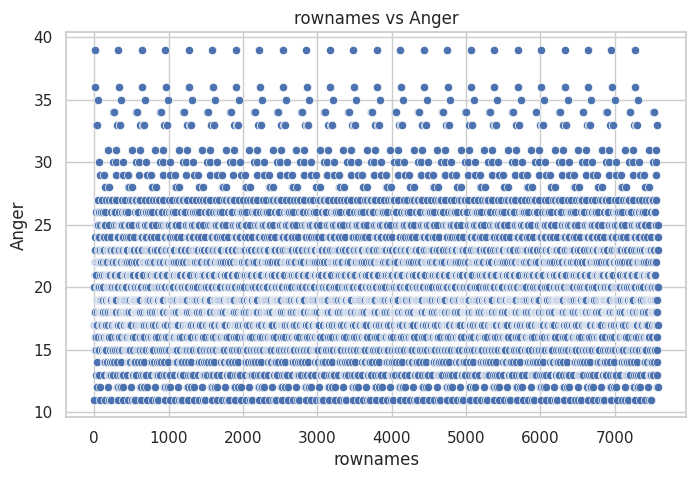

In [68]:
# Scatter plot

x_col = numeric_cols[0]
y_col = numeric_cols[1]

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_phase2,
    x=x_col,
    y=y_col
)

plt.title(f"{x_col} vs {y_col}")
plt.xlabel(x_col)
plt.ylabel(y_col)

plt.show()

In [69]:
# Pearson correlation

from scipy.stats import pearsonr

r, p = pearsonr(
    df_phase2[x_col],
    df_phase2[y_col]
)

print("Pearson Correlation:", r)
print("P-value:", p)

Pearson Correlation: -0.002112727366477697
P-value: 0.8540454621867523


3D Statistical Analysis

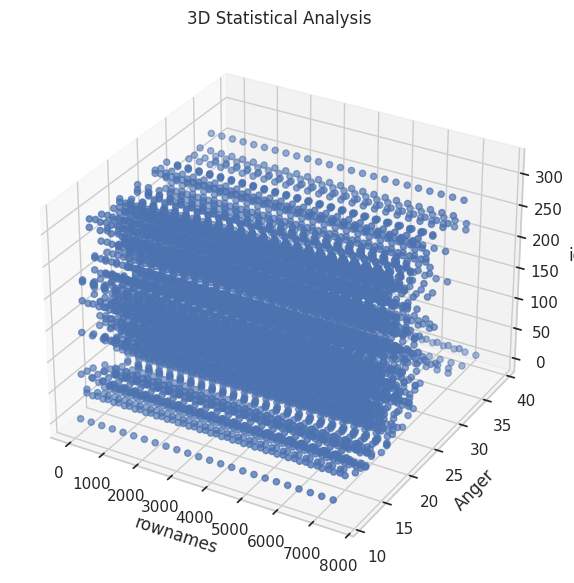

In [70]:
# 3D scatter plot

from mpl_toolkits.mplot3d import Axes3D

x_col = numeric_cols[0]
y_col = numeric_cols[1]
z_col = numeric_cols[2]

fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df_phase2[x_col],
    df_phase2[y_col],
    df_phase2[z_col]
)

ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.set_zlabel(z_col)

plt.title("3D Statistical Analysis")

plt.show()

K-Means Clustering

In [71]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Prepare data for clustering

cluster_data = df_phase2[numeric_cols].copy()

scaler_phase2 = StandardScaler()

X = scaler_phase2.fit_transform(cluster_data)

print("Clustering data shape:", X.shape)

Clustering data shape: (7584, 3)


In [72]:
# Elbow Method

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    inertia.append(kmeans.inertia_)

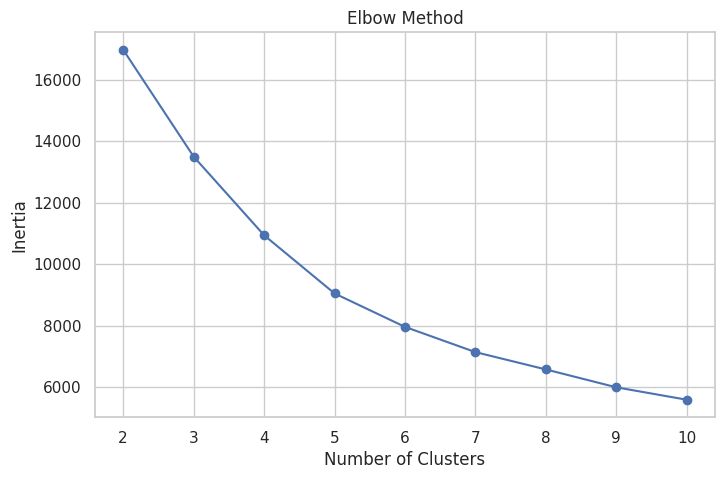

In [73]:
# Elbow plot

plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [74]:
# Apply K-Means clustering

optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)

df_phase2["KMeans_Cluster"] = kmeans_labels

print("Cluster distribution:")
print(
    df_phase2["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

Cluster distribution:
KMeans_Cluster
0    1005
1    1702
2    1698
3    1582
4    1597
Name: count, dtype: int64


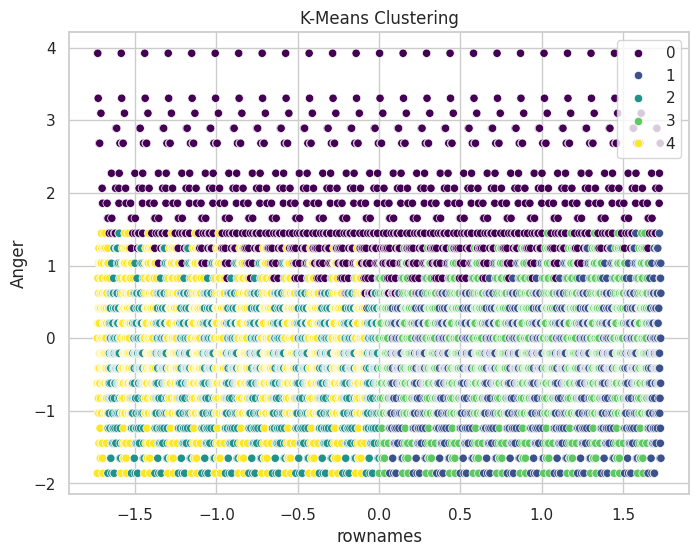

In [75]:
# K-Means visualization

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=kmeans_labels,
    palette="viridis"
)

plt.xlabel(numeric_cols[0])
plt.ylabel(numeric_cols[1])
plt.title("K-Means Clustering")

plt.show()

In [76]:
# K-Means Silhouette Score

kmeans_score = silhouette_score(
    X,
    kmeans_labels
)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.2665487472805624


 Hierarchical Clustering

In [78]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

sample_size = min(100, len(X))

sample_indices = np.random.RandomState(42).choice(
    len(X),
    size=sample_size,
    replace=False
)

X_sample = X[sample_indices]

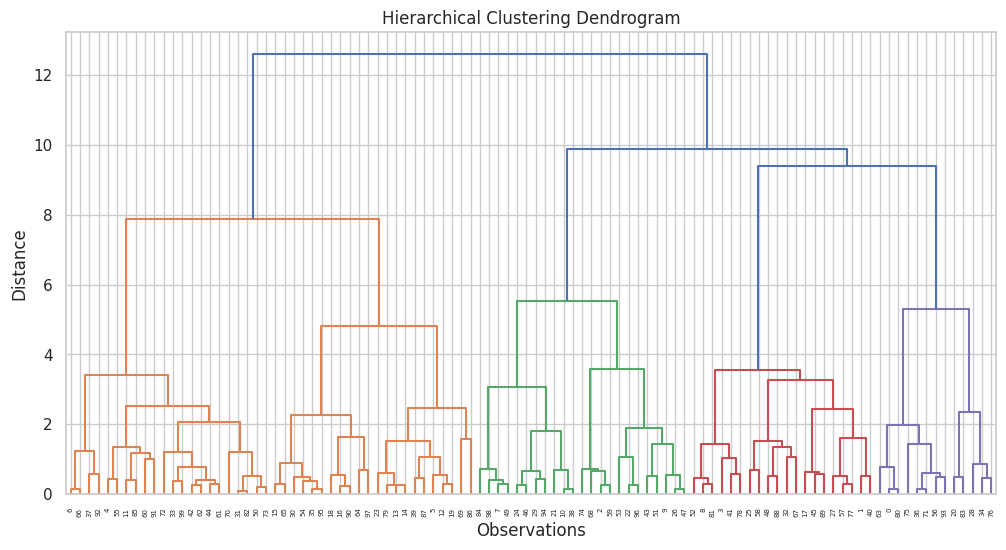

In [79]:
# Hierarchical clustering using Ward linkage

Z = linkage(
    X_sample,
    method="ward"
)

plt.figure(figsize=(12,6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")

plt.show()

In [80]:
# Create hierarchical clusters

hierarchical_labels = fcluster(
    Z,
    t=optimal_k,
    criterion="maxclust"
)

print("Hierarchical Cluster Distribution:")

print(
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
)

Hierarchical Cluster Distribution:
1    22
2    22
3    23
4    20
5    13
Name: count, dtype: int64


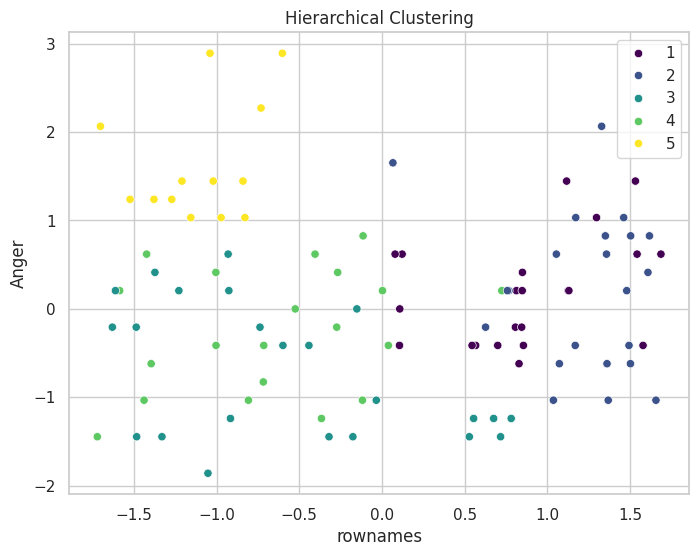

In [81]:
# Hierarchical clustering visualization

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_sample[:, 0],
    y=X_sample[:, 1],
    hue=hierarchical_labels,
    palette="viridis"
)

plt.xlabel(numeric_cols[0])
plt.ylabel(numeric_cols[1])
plt.title("Hierarchical Clustering")

plt.show()

In [83]:
# Silhouette Score for Hierarchical Clustering

hierarchical_score = silhouette_score(
    X_sample,
    hierarchical_labels
)

print(
    "Hierarchical Clustering Silhouette Score:",
    hierarchical_score
)

Hierarchical Clustering Silhouette Score: 0.2766405193067788


Clustering Comparison

In [84]:
# Compare clustering methods

comparison = pd.DataFrame({
    "Method": [
        "K-Means",
        "Hierarchical Clustering"
    ],
    "Number of Clusters": [
        optimal_k,
        optimal_k
    ],
    "Silhouette Score": [
        kmeans_score,
        hierarchical_score
    ]
})

comparison

,Method,Number of Clusters,Silhouette Score
0,K-Means,5,0.266549
1,Hierarchical Clustering,5,0.276641


## Conclusion

Phase II performed 1D, 2D and 3D statistical analyses to study the distribution and relationships within the dataset.
K-Means clustering was applied using the Elbow Method and evaluated using the Silhouette Score.
Hierarchical clustering was performed using Ward linkage and evaluated using its Silhouette Score.
These analyses provided deeper insights into the statistical relationships and clustering structure of the dataset.